In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!ls "/content/drive/MyDrive/175/spider_data"

Mounted at /content/drive
database      README.txt     test_gold.sql     train_gold.sql
dev_gold.sql  tables.json    test.json	       train_others.json
dev.json      test_database  test_tables.json  train_spider.json


In [ ]:
!pip install openai sqlite-utils tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 1.4 MB/s eta 0:00:00


In [ ]:
import os
from openai import OpenAI
from google.colab import userdata

api_key = userdata.get('API_KEY')

os.environ["OPENAI_API_KEY"] = api_key

client = OpenAI()

In [ ]:
import json

base_path = "/content/drive/MyDrive/175/spider_data"

with open(f"{base_path}/dev.json") as f:
    dev_data = json.load(f)

with open(f"{base_path}/tables.json") as f:
    tables = json.load(f)

print("Examples:", len(dev_data))

Examples: 1034


In [ ]:
from collections import defaultdict

schema_dict = {}

for db in tables:
    db_id = db["db_id"]
    table_names = db["table_names_original"]
    column_names = db["column_names_original"]

    table_columns = defaultdict(list)

    for table_idx, column_name in column_names:
        if table_idx == -1:
            continue
        table_name = table_names[table_idx]
        table_columns[table_name].append(column_name)

    schema_text = ""

    for table, cols in table_columns.items():
        schema_text += f"Table {table}({', '.join(cols)})\n"

    schema_dict[db_id] = schema_text

In [ ]:
def build_prompt(question, schema):

    prompt = f"""
You are an expert SQL generator.

Given a database schema and a natural language question,
generate a valid SQLite SQL query.

Return ONLY the SQL query.
Do not include explanations or markdown.

Schema:
{schema}

Question:
{question}

SQL:
"""

    return prompt

In [ ]:
def generate_sql(question, schema):

    prompt = build_prompt(question, schema)

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0
    )

    sql = response.output[0].content[0].text.strip()

    return sql

In [ ]:
import sqlite3

def execute_sql(db_id, sql):

    db_path = f"{base_path}/database/{db_id}/{db_id}.sqlite"

    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        cursor.execute(sql)
        result = cursor.fetchall()

        conn.close()

        return result, None

    except Exception as e:
        return None, str(e)

In [ ]:
from tqdm import tqdm

correct = 0
total = 0

for ex in tqdm(dev_data[:100]):  # start with 100 examples

    question = ex["question"]
    gold_sql = ex["query"]
    db_id = ex["db_id"]

    schema = schema_dict[db_id]

    pred_sql = generate_sql(question, schema)

    gold_result = execute_sql(db_id, gold_sql)
    pred_result = execute_sql(db_id, pred_sql)

    is_correct = (gold_result == pred_result and gold_result is not None)

    if is_correct:
      correct += 1

    total += 1

print("Execution Accuracy:", correct / total)

# 100%|██████████| 100/100 [02:13<00:00,  1.34s/it]Execution Accuracy: 0.71

100%|██████████| 100/100 [02:13<00:00,  1.34s/it]

Execution Accuracy: 0.71


In [ ]:
# Prompt with Few-Shot Examples

def build_few_shot_prompt(question, schema):

    prompt = f"""
You are an expert SQL generator for SQLite databases.

Think step-by-step about which tables and columns are needed.
Then write the SQL query.

Return ONLY the SQL query. Use valid SQLite syntax.

Example 1
Schema:
Table singer(id, name, country)

Question:
How many singers are from France?

SQL:
SELECT COUNT(*) FROM singer WHERE country = 'France';

Example 2
Schema:
Table student(id, name, age)

Question:
What is the average age of students?

SQL:
SELECT AVG(age) FROM student;

Example 3
Schema:
Table singer(id, name, country)
Table concert(id, singer_id, venue)

Question:
List the names of singers who performed in a concert.

SQL:
SELECT DISTINCT singer.name
FROM singer
JOIN concert ON singer.id = concert.singer_id;

Example 4
Schema:
Table student(id, name)
Table enrollment(student_id, course_id)
Table course(id, title)

Question:
List the names of students enrolled in any course.

SQL:
SELECT DISTINCT student.name
FROM student
JOIN enrollment ON student.id = enrollment.student_id
JOIN course ON enrollment.course_id = course.id;

---

Schema:
{schema}

Question:
{question}

SQL:
"""

    return prompt

def generate_sql(question, schema):

    prompt = build_few_shot_prompt(question, schema)

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0
    )

    sql = response.output[0].content[0].text.strip()

    return sql

In [ ]:
from tqdm import tqdm

results = []

correct = 0
total = 0

for ex in tqdm(dev_data[:100]):  # start with 100 examples

    question = ex["question"]
    gold_sql = ex["query"]
    db_id = ex["db_id"]

    schema = schema_dict[db_id]

    pred_sql = generate_sql(question, schema)

    gold_result = execute_sql(db_id, gold_sql)
    pred_result = execute_sql(db_id, pred_sql)

    is_correct = (gold_result == pred_result and gold_result is not None)

    if is_correct:
      correct += 1

    total += 1

    results.append({
        "db_id": db_id,
        "question": question,
        "gold_sql": gold_sql,
        "predicted_sql": pred_sql,
        "gold_result": str(gold_result),
        "pred_result": str(pred_result),
        "execution_correct": is_correct
    })

print("Execution Accuracy:", correct / total)

# 100%|██████████| 100/100 [02:12<00:00,  1.33s/it]Execution Accuracy: 0.73

100%|██████████| 100/100 [02:12<00:00,  1.33s/it]

Execution Accuracy: 0.73


In [ ]:
import json

output_path = "/content/drive/MyDrive/175/outputs/spider_results_gpt.json"

with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

In [ ]:
import pandas as pd
import re

df = pd.read_json("/content/drive/MyDrive/175/outputs/spider_results_gpt.json")

errors = df[df["execution_correct"] == False]

def detect_syntax_error(row):
    return row["pred_result"] == "None"

def extract_tables(sql):
    return re.findall(r'FROM\s+(\w+)|JOIN\s+(\w+)', sql, re.IGNORECASE)

def clean_tables(matches):
    tables = []
    for m in matches:
        tables.extend([x for x in m if x])
    return tables

def hallucinated_table(row):
    pred_tables = set(clean_tables(extract_tables(row["predicted_sql"])))
    gold_tables = set(clean_tables(extract_tables(row["gold_sql"])))

    return len(pred_tables - gold_tables) > 0

def extract_columns(sql):
  return re.findall(r'\b\w+\.\w+\b', sql)

def hallucinated_column(row):
    pred_cols = set(extract_columns(row["predicted_sql"]))
    gold_cols = set(extract_columns(row["gold_sql"]))

    return len(pred_cols - gold_cols) > 0

def aggregation_error(row):
    gold_has_agg = any(x in row["gold_sql"].lower() for x in ["count(", "avg(", "sum(", "max(", "min("])
    pred_has_agg = any(x in row["predicted_sql"].lower() for x in ["count(", "avg(", "sum(", "max(", "min("])

    return gold_has_agg and not pred_has_agg

def join_error(row):

    gold_has_join = "join" in row["gold_sql"].lower()
    pred_has_join = "join" in row["predicted_sql"].lower()

    return gold_has_join and not pred_has_join

def categorize_error(row):

    if row["pred_result"] == "None":
        return "execution_or_syntax_error"

    if hallucinated_table(row):
        return "hallucinated_table"

    if hallucinated_column(row):
        return "hallucinated_column"

    if aggregation_error(row):
        return "aggregation_error"

    if join_error(row):
        return "join_error"

    return "semantic_error"

errors["error_type"] = errors.apply(categorize_error, axis=1)
error_distribution = errors["error_type"].value_counts(normalize=True) * 100

print(error_distribution)

'''
error_type
hallucinated_table     62.962963
hallucinated_column    18.518519
join_error             11.111111
semantic_error          7.407407
'''

error_type
hallucinated_table     62.962963
hallucinated_column    18.518519
join_error             11.111111
semantic_error          7.407407
Name: proportion, dtype: float64


/tmp/ipykernel_308/1288781149.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors["error_type"] = errors.apply(categorize_error, axis=1)


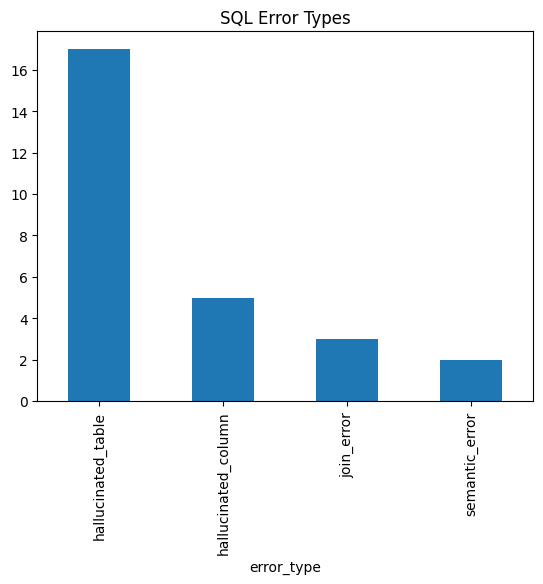

In [ ]:
import matplotlib.pyplot as plt

errors["error_type"].value_counts().plot(kind="bar")
plt.title("SQL Error Types")
plt.show()